In [1]:
#First execute this cell go to Runtime and click on Restart Runtime
!pip install --upgrade --no-deps statsmodels
!pip install  StatsForecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


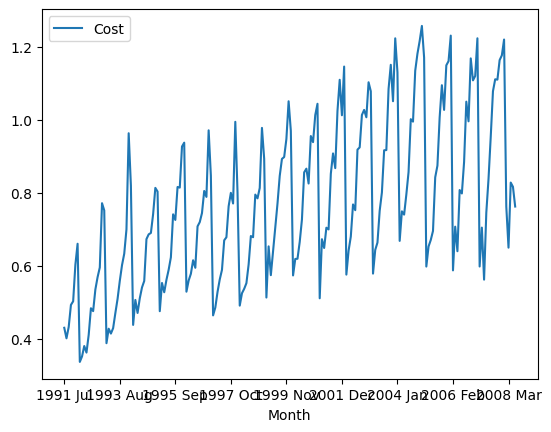

In [2]:
import pandas as pd
from matplotlib import pyplot
ap1=pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/h02.csv')
ap1=ap1.set_index('Month')
ap1.plot()
pyplot.show()


In [3]:
ap1

,Cost
Month,
1991 Jul,0.429795
1991 Aug,0.400906
1991 Sep,0.432159
1991 Oct,0.492543
1991 Nov,0.502369
...,...
2008 Feb,0.761822
2008 Mar,0.649435
2008 Apr,0.827887


Using the above data set

1)Test stationary of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

2)Take difference and seasonal difference and test stationay of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

3) Plot ACF and PACF of series if series' difference and seasonal difference taken .

4) Based on the plot of ACF and PACF, come up with two SARIMA model and compare their Akaike Information Criterion metric.

5)Split data into train and test. For the test data, use last 12 months observation.

6)Plot test, train and forecast values for the SARIMA model chosen at Q4. Evaluate performance of the model in terms of MAE(mean absulate error), MAPE(mean absulate percentage error) and MSE(Mean squared Error).

7) Using the Statsforecast library, implement the following models: AutoARIMA, AutoETS, HoltWinters,  AutoTheta, and MSTL and plot the forecast of this model .Evaluate the performance of these model model using  MSE (Mean Squared Error).Note that seasonality period is 12.


### Question 1: Test stationarity of the dataset.

In [4]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the 'Cost' column of ap1
result = adfuller(ap1['Cost'])

# Null Hypothesis (H0): The time series is non-stationary (it has a unit root).
# Alternative Hypothesis (H1): The time series is stationary (it does not have a unit root).

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

alpha = 0.05 # 5% significance level

if result[1] > alpha:
    print(f"Conclusion at {alpha*100}% significance level: The p-value ({result[1]:.3f}) is greater than the significance level ({alpha}), so we fail to reject the null hypothesis. The series is non-stationary (it has a unit root).")
else:
    print(f"Conclusion at {alpha*100}% significance level: The p-value ({result[1]:.3f}) is less than or equal to the significance level ({alpha}), so we reject the null hypothesis. The series is stationary (it does not have a unit root).")

ADF Statistic: -1.696756
p-value: 0.432785
Critical Values:
	1%: -3.466
	5%: -2.877
	10%: -2.575
Conclusion at 5.0% significance level: The p-value (0.433) is greater than the significance level (0.05), so we fail to reject the null hypothesis. The series is non-stationary (it has a unit root).


### Question 2: Take difference and seasonal difference and test stationarity of the dataset.

Original Series Head:
 Month
1991 Jul    0.429795
1991 Aug    0.400906
1991 Sep    0.432159
1991 Oct    0.492543
1991 Nov    0.502369
Name: Cost, dtype: float64

First Differenced Series Head:
 Month
1991 Aug   -0.028889
1991 Sep    0.031253
1991 Oct    0.060384
1991 Nov    0.009826
1991 Dec    0.100283
Name: Cost, dtype: float64

Seasonally Differenced Series Head:
 Month
1992 Aug    0.020964
1992 Sep    0.028045
1992 Oct   -0.026539
1992 Nov    0.016791
1992 Dec    0.075751
Name: Cost, dtype: float64


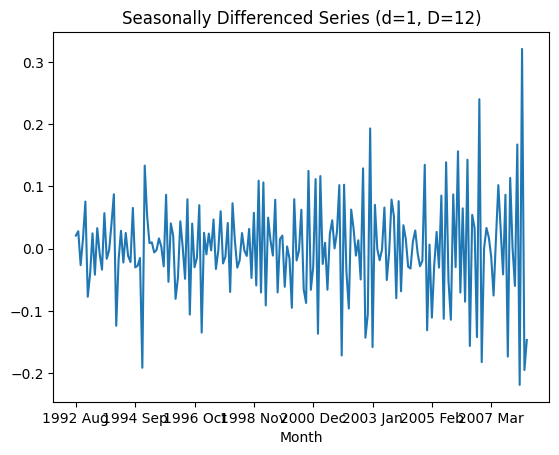

In [5]:
import numpy as np

# Take the first difference
ap1_diff = ap1['Cost'].diff().dropna()

# Take the seasonal difference (assuming seasonality of 12 months, as suggested by later questions)
ap1_seasonal_diff = ap1_diff.diff(12).dropna()

print("Original Series Head:\n", ap1['Cost'].head())
print("\nFirst Differenced Series Head:\n", ap1_diff.head())
print("\nSeasonally Differenced Series Head:\n", ap1_seasonal_diff.head())

# Plot the seasonally differenced series
ap1_seasonal_diff.plot()
pyplot.title('Seasonally Differenced Series (d=1, D=12)')
pyplot.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the seasonally differenced series
result_seasonal_diff = adfuller(ap1_seasonal_diff)

# Null Hypothesis (H0): The time series is non-stationary (it has a unit root).
# Alternative Hypothesis (H1): The time series is stationary (it does not have a unit root).

print('ADF Statistic (Seasonally Differenced): %f' % result_seasonal_diff[0])
print('p-value (Seasonally Differenced): %f' % result_seasonal_diff[1])
print('Critical Values:')
for key, value in result_seasonal_diff[4].items():
    print('\t%s: %.3f' % (key, value))

alpha = 0.05 # 5% significance level

if result_seasonal_diff[1] > alpha:
    print(f"Conclusion at {alpha*100}% significance level: The p-value ({result_seasonal_diff[1]:.3f}) is greater than the significance level ({alpha}), so we fail to reject the null hypothesis. The series is non-stationary (it has a unit root) after differencing.")
else:
    print(f"Conclusion at {alpha*100}% significance level: The p-value ({result_seasonal_diff[1]:.3f}) is less than or equal to the significance level ({alpha}), so we reject the null hypothesis. The series is stationary (it does not have a unit root) after differencing.")

ADF Statistic (Seasonally Differenced): -5.070403
p-value (Seasonally Differenced): 0.000016
Critical Values:
	1%: -3.468
	5%: -2.878
	10%: -2.576
Conclusion at 5.0% significance level: The p-value (0.000) is less than or equal to the significance level (0.05), so we reject the null hypothesis. The series is stationary (it does not have a unit root) after differencing.


### Question 3: Plot ACF and PACF of series if series' difference and seasonal difference taken.

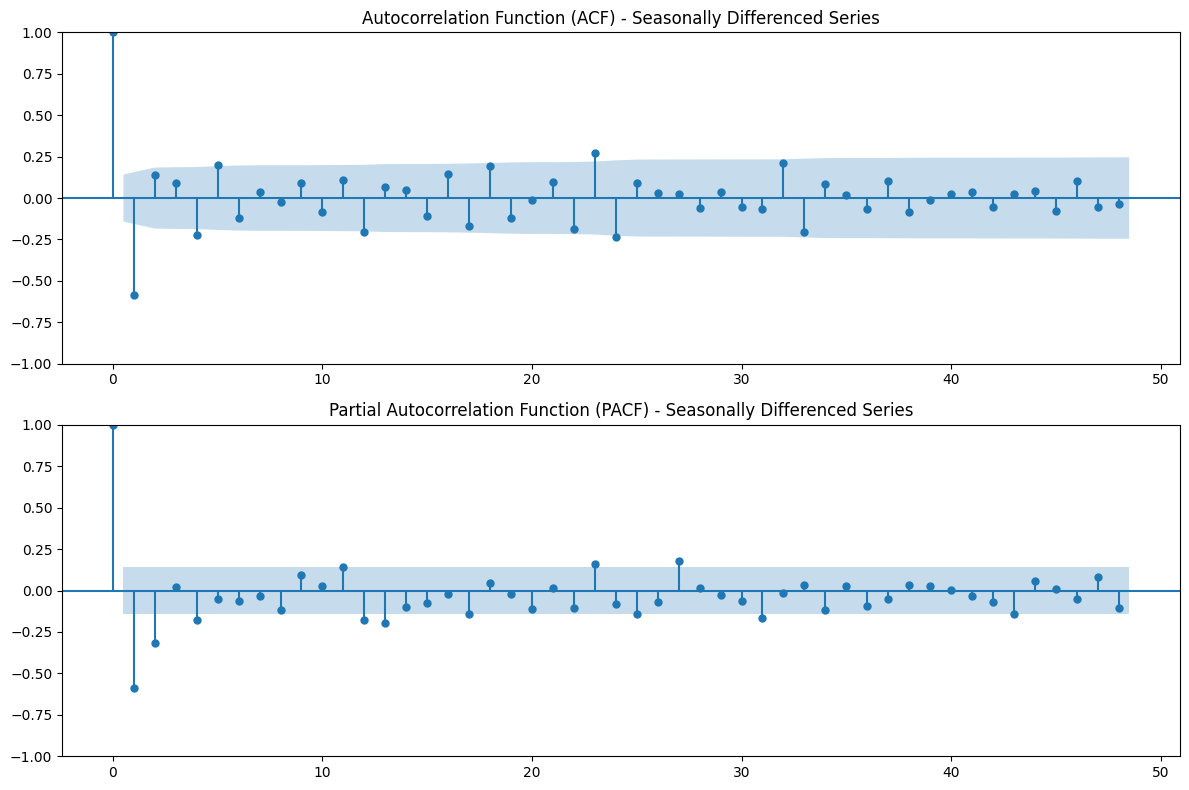

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the seasonally differenced series
fig, axes = pyplot.subplots(2, 1, figsize=(12, 8))

plot_acf(ap1_seasonal_diff, lags=48, ax=axes[0]) # Lags up to 4 years (4 * 12 = 48)
axes[0].set_title('Autocorrelation Function (ACF) - Seasonally Differenced Series')

plot_pacf(ap1_seasonal_diff, lags=48, ax=axes[1]) # Lags up to 4 years (4 * 12 = 48)
axes[1].set_title('Partial Autocorrelation Function (PACF) - Seasonally Differenced Series')

pyplot.tight_layout()
pyplot.show()

### Question 4: Based on the plot of ACF and PACF, come up with two SARIMA model and compare their Akaike Information Criterion metric.

Based on the ACF and PACF plots of the seasonally differenced series (`ap1_seasonal_diff`):

**Observations:**

*   **ACF:**
    *   There's a significant spike at lag 1, suggesting a non-seasonal MA(1) component.
    *   There's a significant spike at lag 12 (and possibly 24), suggesting a seasonal MA(1) or MA(2) component at the seasonal period of 12.
    *   The ACF generally tails off after lag 12.

*   **PACF:**
    *   There's a significant spike at lag 1, suggesting a non-seasonal AR(1) component.
    *   There's a significant spike at lag 12, suggesting a seasonal AR(1) component.
    *   The PACF generally tails off after lag 12.

**Proposed Models (d=1, D=12 based on previous differencing):**

1.  **SARIMA(1,1,1)(1,1,1,12):** This model incorporates AR(1) and MA(1) non-seasonal components and seasonal AR(1) and MA(1) components at lag 12, which seems plausible given the spikes at lags 1 and 12 in both ACF and PACF.
2.  **SARIMA(0,1,1)(0,1,1,12):** This model suggests that only the moving average components are significant, both non-seasonal and seasonal. This is often a good starting point if the ACF shows a sharp cutoff at lag 1 and 12, and the PACF trails off.

Let's fit these two models and compare their AIC.

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the seasonal period
seasonal_period = 12

# Model 1: SARIMA(1,1,1)(1,1,1,12)
model1 = SARIMAX(ap1['Cost'], order=(1, 1, 1), seasonal_order=(1, 1, 1, seasonal_period),
                 enforce_stationarity=False, enforce_invertibility=False)
results1 = model1.fit(disp=False)
print('SARIMA(1,1,1)(1,1,1,12) - AIC: %.3f' % results1.aic)

# Model 2: SARIMA(0,1,1)(0,1,1,12)
model2 = SARIMAX(ap1['Cost'], order=(0, 1, 1), seasonal_order=(0, 1, 1, seasonal_period),
                 enforce_stationarity=False, enforce_invertibility=False)
results2 = model2.fit(disp=False)
print('SARIMA(0,1,1)(0,1,1,12) - AIC: %.3f' % results2.aic)

print('\nComparison of AIC values:')
if results1.aic < results2.aic:
    print(f'SARIMA(1,1,1)(1,1,1,12) has a lower AIC ({results1.aic:.3f}) and is generally preferred.')
else:
    print(f'SARIMA(0,1,1)(0,1,1,12) has a lower AIC ({results2.aic:.3f}) and is generally preferred.')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA(1,1,1)(1,1,1,12) - AIC: -509.700


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA(0,1,1)(0,1,1,12) - AIC: -506.622

Comparison of AIC values:
SARIMA(1,1,1)(1,1,1,12) has a lower AIC (-509.700) and is generally preferred.


### Question 5: Split data into train and test. For the test data, use last 12 months observation.

In [9]:
train_size = len(ap1) - 12
train_data = ap1.iloc[:train_size]
test_data = ap1.iloc[train_size:]

print(f"Training data size: {len(train_data)} observations")
print(f"Test data size: {len(test_data)} observations")
print("\nLast 5 training observations:\n", train_data.tail())
print("\nFirst 5 test observations:\n", test_data.head())

Training data size: 192 observations
Test data size: 12 observations

Last 5 training observations:
               Cost
Month             
2007 Feb  0.597753
2007 Mar  0.704398
2007 Apr  0.561760
2007 May  0.745258
2007 Jun  0.837934

First 5 test observations:
               Cost
Month             
2007 Jul  0.954144
2007 Aug  1.078219
2007 Sep  1.110982
2007 Oct  1.109979
2007 Nov  1.163534


### Question 6: Plot test, train and forecast values for the SARIMA model chosen at Q4. Evaluate performance of the model in terms of MAE(mean absolute error), MAPE(mean absolute percentage error) and MSE(Mean squared Error).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


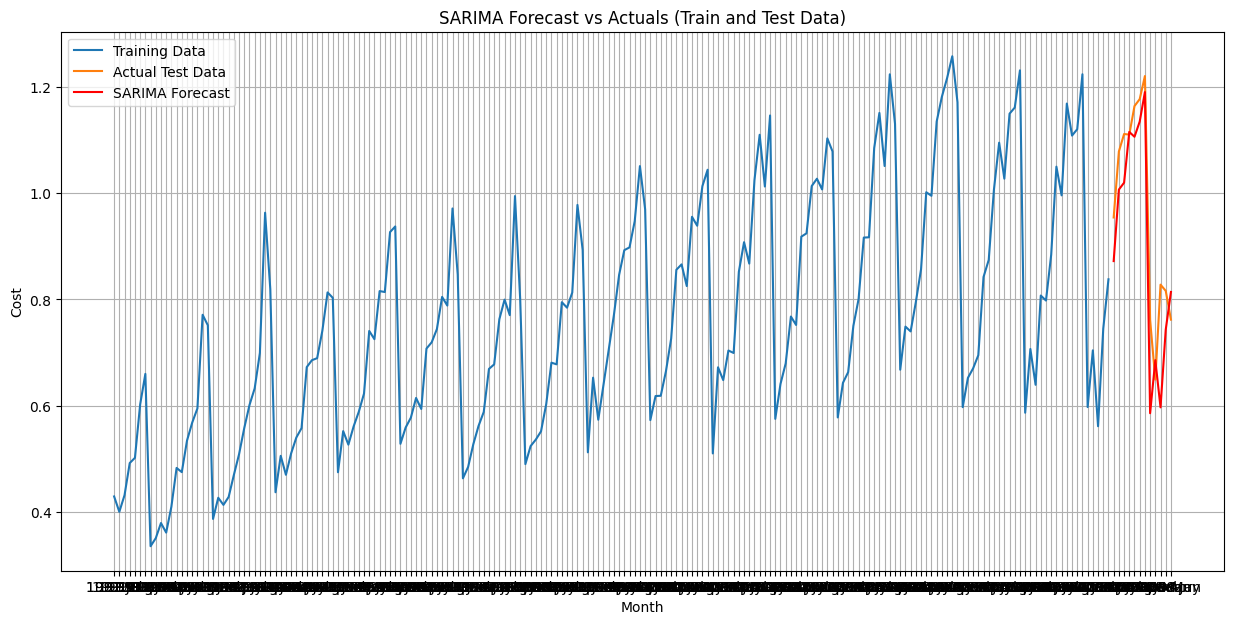

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Re-fit the chosen SARIMA model on the training data
# The chosen model was SARIMA(1,1,1)(1,1,1,12) based on AIC comparison
model_chosen = SARIMAX(train_data['Cost'], order=(1, 1, 1), seasonal_order=(1, 1, 1, seasonal_period),
                       enforce_stationarity=False, enforce_invertibility=False)
results_chosen = model_chosen.fit(disp=False)

# Make predictions on the test set
start = len(train_data)
end = len(ap1) - 1
forecast_sarima = results_chosen.predict(start=start, end=end, dynamic=False)

# Ensure the forecast index matches the test_data index for plotting and evaluation
forecast_sarima.index = test_data.index

# Plotting train, test, and forecast
pyplot.figure(figsize=(15, 7))
pyplot.plot(train_data.index, train_data['Cost'], label='Training Data')
pyplot.plot(test_data.index, test_data['Cost'], label='Actual Test Data')
pyplot.plot(forecast_sarima.index, forecast_sarima, label='SARIMA Forecast', color='red')
pyplot.title('SARIMA Forecast vs Actuals (Train and Test Data)')
pyplot.xlabel('Month')
pyplot.ylabel('Cost')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

In [11]:
# Evaluate performance metrics

# Mean Absolute Error (MAE)
mae = mean_absolute_error(test_data['Cost'], forecast_sarima)
print(f'Mean Absolute Error (MAE): {mae:.4f}')

# Mean Squared Error (MSE)
mse = mean_squared_error(test_data['Cost'], forecast_sarima)
print(f'Mean Squared Error (MSE): {mse:.4f}')

# Mean Absolute Percentage Error (MAPE)
# Avoid division by zero by adding a small epsilon or handling zero values
# Assuming 'Cost' values are non-negative and generally not zero in this context
mape = np.mean(np.abs((test_data['Cost'] - forecast_sarima) / test_data['Cost'])) * 100
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

Mean Absolute Error (MAE): 0.0790
Mean Squared Error (MSE): 0.0100
Mean Absolute Percentage Error (MAPE): 8.94%


### Question 7: Using the Statsforecast library, implement the following models: AutoARIMA, AutoETS, HoltWinters, AutoTheta, and MSTL and plot the forecast of this model. Evaluate the performance of these model model using MSE (Mean Squared Error). Note that seasonality period is 12.

/tmp/ipykernel_1814/1556775848.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  full_data['ds'] = pd.to_datetime(full_data['ds'])


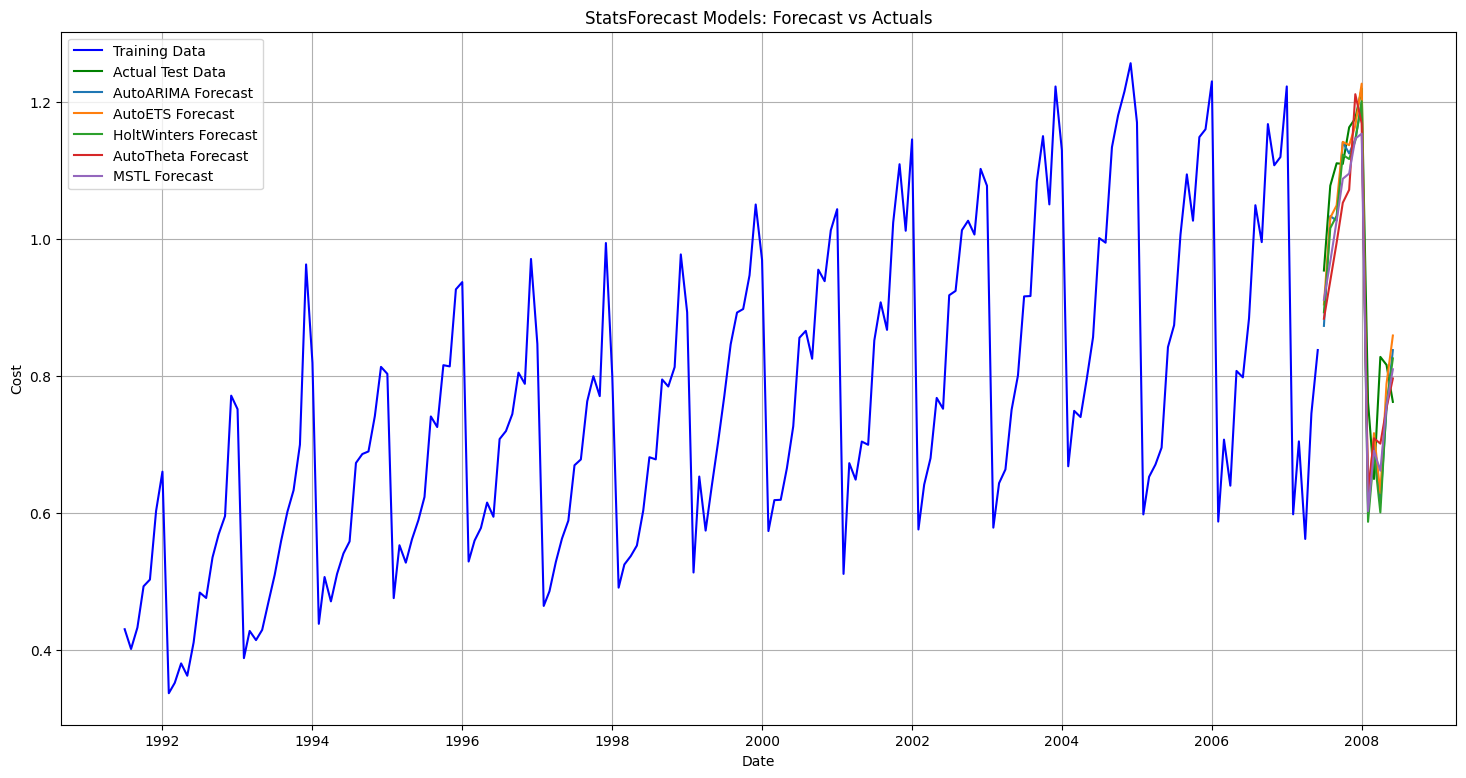

In [16]:
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, HoltWinters, AutoTheta, MSTL
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Prepare data for StatsForecast
# StatsForecast expects a DataFrame with columns: unique_id, ds, y

# Combine train and test data for easier processing
full_data = ap1.reset_index().rename(columns={'Month': 'ds', 'Cost': 'y'})
full_data['unique_id'] = '1' # Single time series

# Convert 'ds' to datetime objects for StatsForecast
full_data['ds'] = pd.to_datetime(full_data['ds'])

# Split into train and test as before
train_df = full_data.iloc[:train_size]
test_df = full_data.iloc[train_size:]

# Define the models
models = [
    AutoARIMA(season_length=seasonal_period),
    AutoETS(season_length=seasonal_period),
    HoltWinters(season_length=seasonal_period),
    AutoTheta(season_length=seasonal_period),
    MSTL(season_length=seasonal_period) # Removed 'reps' argument
]

# Create StatsForecast object
sf = StatsForecast(
    models=models,
    freq='MS', # Monthly frequency
    n_jobs=-1  # Use all available cores
)

# Fit the models on the training data
sf.fit(train_df)

# Make forecasts for the test period
h = len(test_df) # Forecast horizon is the length of the test data
forecast_sf = sf.predict(h=h)

# Merge forecasts with actual test data for evaluation and plotting
forecast_df = test_df.merge(forecast_sf, on=['ds', 'unique_id'], how='left')


# Plotting forecasts
plt.figure(figsize=(18, 9))
plt.plot(train_df['ds'], train_df['y'], label='Training Data', color='blue')
plt.plot(test_df['ds'], test_df['y'], label='Actual Test Data', color='green')

for model_name in forecast_sf.columns:
    if model_name not in ['unique_id', 'ds']:
        plt.plot(forecast_df['ds'], forecast_df[model_name], label=f'{model_name} Forecast')

plt.title('StatsForecast Models: Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Evaluate performance of each StatsForecast model using MSE
print('Mean Squared Error (MSE) for StatsForecast Models:')

for model_name in forecast_sf.columns:
    if model_name not in ['unique_id', 'ds']:
        mse = mean_squared_error(test_df['y'], forecast_df[model_name])
        print(f'{model_name}: {mse:.4f}')

Mean Squared Error (MSE) for StatsForecast Models:
AutoARIMA: 0.0083
AutoETS: 0.0072
HoltWinters: 0.0090
AutoTheta: 0.0079
MSTL: 0.0077
